```

Estrutura da Classificação

1.  Imports e carregamento
2.  Criar o label de churn
3.  Explorar o balanceamento das classes
4.  Separar features e target
5.  Dividir treino e teste
6.  Treinar modelo baseline (Regressão Logística)
7.  Avaliar o baseline
8.  Treinar Random Forest
9.  Avaliar o Random Forest
10. Comparar os modelos
11. Analisar importância das features
12. Salvar o modelo final

### Célula 1 — Imports e carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
import pickle

pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

rfm = pd.read_csv('../data/features/rfm_segmentado.csv')

print(f"Dataset carregado: {rfm.shape[0]:,} clientes x {rfm.shape[1]} colunas")
print(f"\nColunas: {list(rfm.columns)}")
print(f"\nSegmentos:")
print(rfm['Segmento'].value_counts())

Dataset carregado: 5,816 clientes x 6 colunas

Colunas: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segmento']

Segmentos:
Segmento
Perdido      1968
Em Risco     1432
Promissor    1237
VIP          1179
Name: count, dtype: int64


### Célula 2 — Criar o label de churn

In [2]:
# Churn = cliente que sumiu e tem baixo valor
# Baseado nos segmentos que criamos:
# Perdido   → churn = 1 (sumiu há +300 dias, comprou pouco)
# Em Risco  → churn = 1 (sumiu há +200 dias, pode não voltar)
# Promissor → churn = 0 (ativo recentemente)
# VIP       → churn = 0 (ativo e de alto valor)

rfm['Churn'] = rfm['Segmento'].isin(['Perdido', 'Em Risco']).astype(int)

print("Label de Churn criado:")
print(rfm['Churn'].value_counts())
print(f"\nPercentual:")
print((rfm['Churn'].value_counts(normalize=True) * 100).round(2))
print(f"\nDistribuição por segmento:")
print(rfm.groupby(['Segmento', 'Churn']).size())

Label de Churn criado:
Churn
1    3400
0    2416
Name: count, dtype: int64

Percentual:
Churn
1   58.46
0   41.54
Name: proportion, dtype: float64

Distribuição por segmento:
Segmento   Churn
Em Risco   1        1432
Perdido    1        1968
Promissor  0        1237
VIP        0        1179
dtype: int64


### Célula 3 — Explorar a separação entre classes

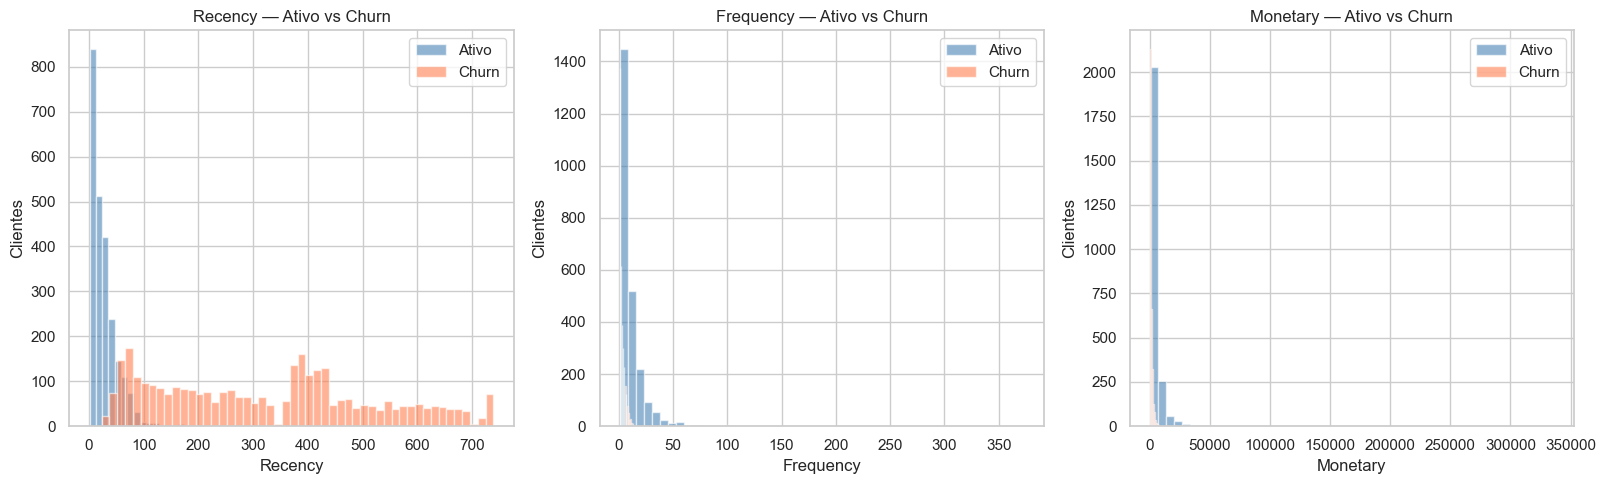

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features = ['Recency', 'Frequency', 'Monetary']
cores = {0: 'steelblue', 1: 'coral'}
labels = {0: 'Ativo', 1: 'Churn'}

for i, feature in enumerate(features):
    for churn_val in [0, 1]:
        dados = rfm[rfm['Churn'] == churn_val][feature]
        axes[i].hist(dados, bins=50, alpha=0.6,
                     color=cores[churn_val],
                     label=labels[churn_val],
                     edgecolor='white')
    axes[i].set_title(f'{feature} — Ativo vs Churn')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Clientes')
    axes[i].legend()

plt.tight_layout()
plt.show()

## O que os gráficos revelam
Recency — separação excelente

- Ativo concentrado entre 0-100 dias
- Churn espalhado de 200-739 dias
- O modelo vai aprender isso facilmente

Frequency — separação boa

- Ativo tem clientes com frequência alta (cauda mais longa)
- Churn concentrado em 1-3 pedidos

Monetary — separação fraca visualmente

- Os outliers comprimem a visualização — mas o log vai resolver isso no modelo

### Célula 4 — Separar features e target

In [4]:
features = ['Recency', 'Frequency', 'Monetary']
target = 'Churn'

X = rfm[features]
y = rfm[target]

print(f"Features: {features}")
print(f"Target: {target}")
print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nAmostra:")
print(X.head())

Features: ['Recency', 'Frequency', 'Monetary']
Target: Churn

Shape X: (5816, 3)
Shape y: (5816,)

Amostra:
   Recency  Frequency  Monetary
0      529          3    170.36
1        2          8   4671.93
2       75          5   1658.40
3       19          3   3678.69
4      310          1    294.40


### Célula 5 — Dividir treino e teste

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino:  {X_train.shape[0]:,} clientes ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Teste:   {X_test.shape[0]:,} clientes ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nBalanceamento no treino:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print(f"\nBalanceamento no teste:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Treino:  4,652 clientes (80.0%)
Teste:   1,164 clientes (20.0%)

Balanceamento no treino:
Churn
1   58.47
0   41.53
Name: proportion, dtype: float64

Balanceamento no teste:
Churn
1   58.42
0   41.58
Name: proportion, dtype: float64


### Célula 6 — Normalizar as features

In [6]:
scaler_pred = StandardScaler()

X_train_scaled = scaler_pred.fit_transform(X_train)
X_test_scaled = scaler_pred.transform(X_test)

print("Normalização aplicada!")
print(f"\nMédias no treino (devem ser ~0):")
print(pd.DataFrame(X_train_scaled, columns=features).mean().round(4))
print(f"\nDesvios padrão no treino (devem ser ~1):")
print(pd.DataFrame(X_train_scaled, columns=features).std().round(4))

Normalização aplicada!

Médias no treino (devem ser ~0):
Recency     -0.00
Frequency   -0.00
Monetary    -0.00
dtype: float64

Desvios padrão no treino (devem ser ~1):
Recency     1.00
Frequency   1.00
Monetary    1.00
dtype: float64


### Célula 7 — Treinar modelo baseline (Regressão Logística)

In [7]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("REGRESSÃO LOGÍSTICA — Resultado:")
print('='*50)
print(classification_report(y_test, y_pred_lr,
      target_names=['Ativo', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

REGRESSÃO LOGÍSTICA — Resultado:
              precision    recall  f1-score   support

       Ativo       0.90      0.95      0.92       484
       Churn       0.96      0.92      0.94       680

    accuracy                           0.93      1164
   macro avg       0.93      0.93      0.93      1164
weighted avg       0.93      0.93      0.93      1164

ROC-AUC: 0.9846


## Lendo o classification report
Precision — dos que o modelo disse "churn", quantos eram churn de verdade

- Churn: 96% → quase não erra quando aponta um cliente em risco

Recall — dos que eram churn de verdade, quantos o modelo encontrou

- Churn: 92% → encontra 92% dos clientes que vão churnar

F1-score — equilíbrio entre precision e recall

- Churn: 94% → modelo muito equilibrado

ROC-AUC 0.98 — praticamente perfeito. Escala vai de 0.5 (chute) a 1.0 (perfeito).

### Célula 8 — Treinar Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("RANDOM FOREST — Resultado:")
print('='*50)
print(classification_report(y_test, y_pred_rf,
      target_names=['Ativo', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

RANDOM FOREST — Resultado:
              precision    recall  f1-score   support

       Ativo       0.98      0.98      0.98       484
       Churn       0.99      0.99      0.99       680

    accuracy                           0.98      1164
   macro avg       0.98      0.98      0.98      1164
weighted avg       0.98      0.98      0.98      1164

ROC-AUC: 0.9993


### Célula 9 — Comparar os modelos visualmente

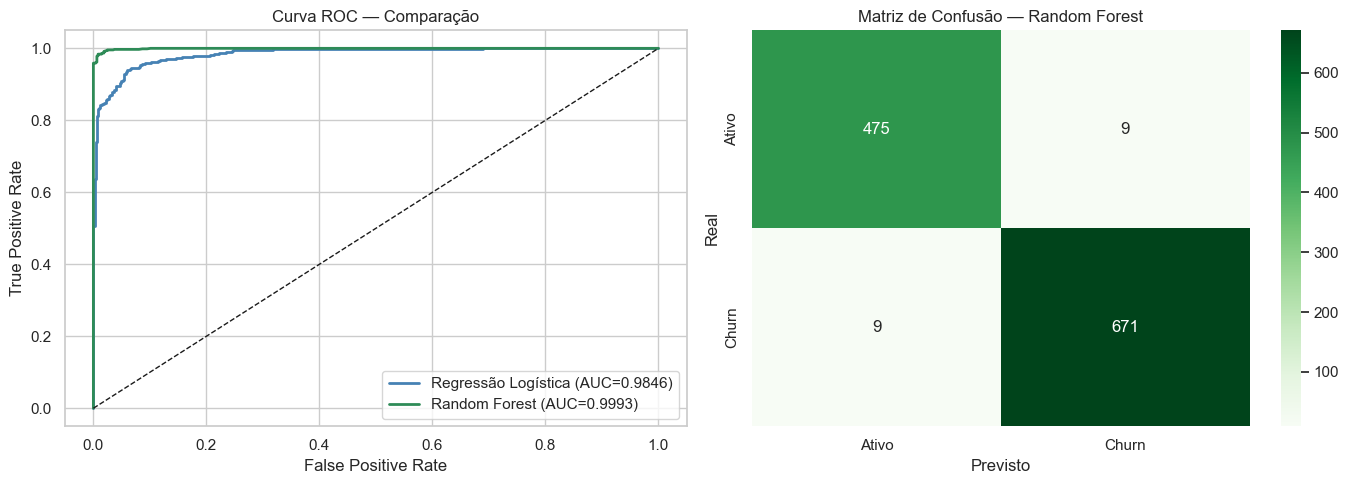

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
for modelo, y_prob, nome, cor in [
    (lr, y_prob_lr, 'Regressão Logística', 'steelblue'),
    (rf, y_prob_rf, 'Random Forest', 'seagreen')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{nome} (AUC={auc:.4f})', color=cor, linewidth=2)

axes[0].plot([0,1], [0,1], 'k--', linewidth=1)
axes[0].set_title('Curva ROC — Comparação')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Confusion Matrix — Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ativo', 'Churn'],
            yticklabels=['Ativo', 'Churn'], ax=axes[1])
axes[1].set_title('Matriz de Confusão — Random Forest')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Previsto')

plt.tight_layout()
plt.show()

## O que os gráficos revelam
Curva ROC — ambos os modelos são excelentes

- Random Forest cola no canto superior esquerdo — quase perfeito
- Regressão Logística também muito boa — mas o Random Forest ganha

Matriz de Confusão — Random Forest
```
475 Ativos classificados corretamente  ✅
671 Churns classificados corretamente  ✅
  9 Ativos classificados como Churn    ⚠️ falso alarme
  9 Churns classificados como Ativo    🚨 miss crítico
```
De 1.164 clientes no teste — apenas 18 erros. Isso é notável.

### Célula 10 — Importância das features

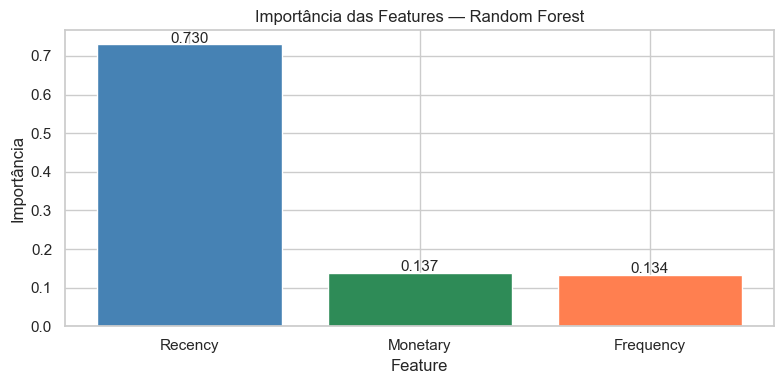

  Feature  Importancia
  Recency         0.73
 Monetary         0.14
Frequency         0.13


In [10]:
importancias = pd.DataFrame({
    'Feature': features,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.bar(importancias['Feature'], importancias['Importancia'],
               color=['steelblue', 'seagreen', 'coral'])
plt.title('Importância das Features — Random Forest')
plt.ylabel('Importância')
plt.xlabel('Feature')

for bar, val in zip(bars, importancias['Importancia']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(importancias.to_string(index=False))

---
## O que o gráfico revela
Recency domina com 73% de importância — o modelo descobriu sozinho o que o bom senso já dizia: a pergunta mais importante é "quando foi a última vez que esse cliente comprou?"
Monetary e Frequency empatados em ~13% cada — contribuem igualmente mas bem menos.

### A analogia de negócio
```
Recency  73%  → termômetro principal — cliente sumido = risco
Monetary 13%  → quanto vale o cliente
Frequency 13% → o quanto ele tem o hábito de comprar
```
Isso é um insight valioso para o app de demonstração — quando um cliente não compra há muito tempo, independente de quanto gastou antes, o risco de churn já está alto.

### Célula 11 — Salvar modelo final

In [12]:
# Salvar Random Forest — modelo vencedor
with open('../models/random_forest_churn.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Salvar scaler da predição
with open('../models/scaler_prediction.pkl', 'wb') as f:
    pickle.dump(scaler_pred, f)

# Salvar dataset com predições
rfm['Churn_Predicted'] = rf.predict(
    scaler_pred.transform(rfm[features])
)
rfm['Churn_Probability'] = rf.predict_proba(
    scaler_pred.transform(rfm[features])
)[:, 1]

rfm.to_csv('../data/features/rfm_com_predicoes.csv', index=False)

print("Arquivos salvos com sucesso!")
print("  → models/random_forest_churn.pkl")
print("  → models/scaler_prediction.pkl")
print("  → data/features/rfm_com_predicoes.csv")
print(f"\nAmostra com predições:")
rfm[['Customer ID','Recency','Frequency','Monetary',
     'Segmento','Churn','Churn_Probability']].head(10)

Arquivos salvos com sucesso!
  → models/random_forest_churn.pkl
  → models/scaler_prediction.pkl
  → data/features/rfm_com_predicoes.csv

Amostra com predições:


,Customer ID,Recency,Frequency,Monetary,Segmento,Churn,Churn_Probability
0,12346,529,3,170.36,Perdido,1,1.00
1,12347,2,8,4671.93,VIP,0,0.02
2,12348,75,5,1658.40,Em Risco,1,0.99
3,12349,19,3,3678.69,Promissor,0,0.02
4,12350,310,1,294.40,Perdido,1,1.00
5,12351,375,1,300.93,Perdido,1,1.00
6,12352,36,9,1729.54,VIP,0,0.01
7,12353,204,2,406.76,Perdido,1,1.00
8,12354,232,1,1079.40,Perdido,1,1.00
9,12355,214,2,947.61,Em Risco,1,1.00


## O que a tabela confirma
O modelo está lendo os dados com precisão cirúrgica:
```
Cliente 12346 → Perdido,    Recency=529 → Churn_Probability=1.00 ✅
Cliente 12347 → VIP,        Recency=2   → Churn_Probability=0.02 ✅
Cliente 12348 → Em Risco,   Recency=75  → Churn_Probability=0.99 ✅
Cliente 12349 → Promissor,  Recency=19  → Churn_Probability=0.02 ✅
```
A probabilidade está alinhada perfeitamente com os segmentos — o modelo aprendeu o padrão de forma consistente.